In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
connection = sqlite3.connect("../data/checking-logs.sqlite")

In [3]:
query = """ 
SELECT numTrials, timestamp, uid
FROM checker
WHERE labname = 'project1'
    AND uid NOT LIKE 'admin%'
    AND status = 'ready';
"""

df = pd.read_sql(query, connection, parse_dates=['timestamp'])

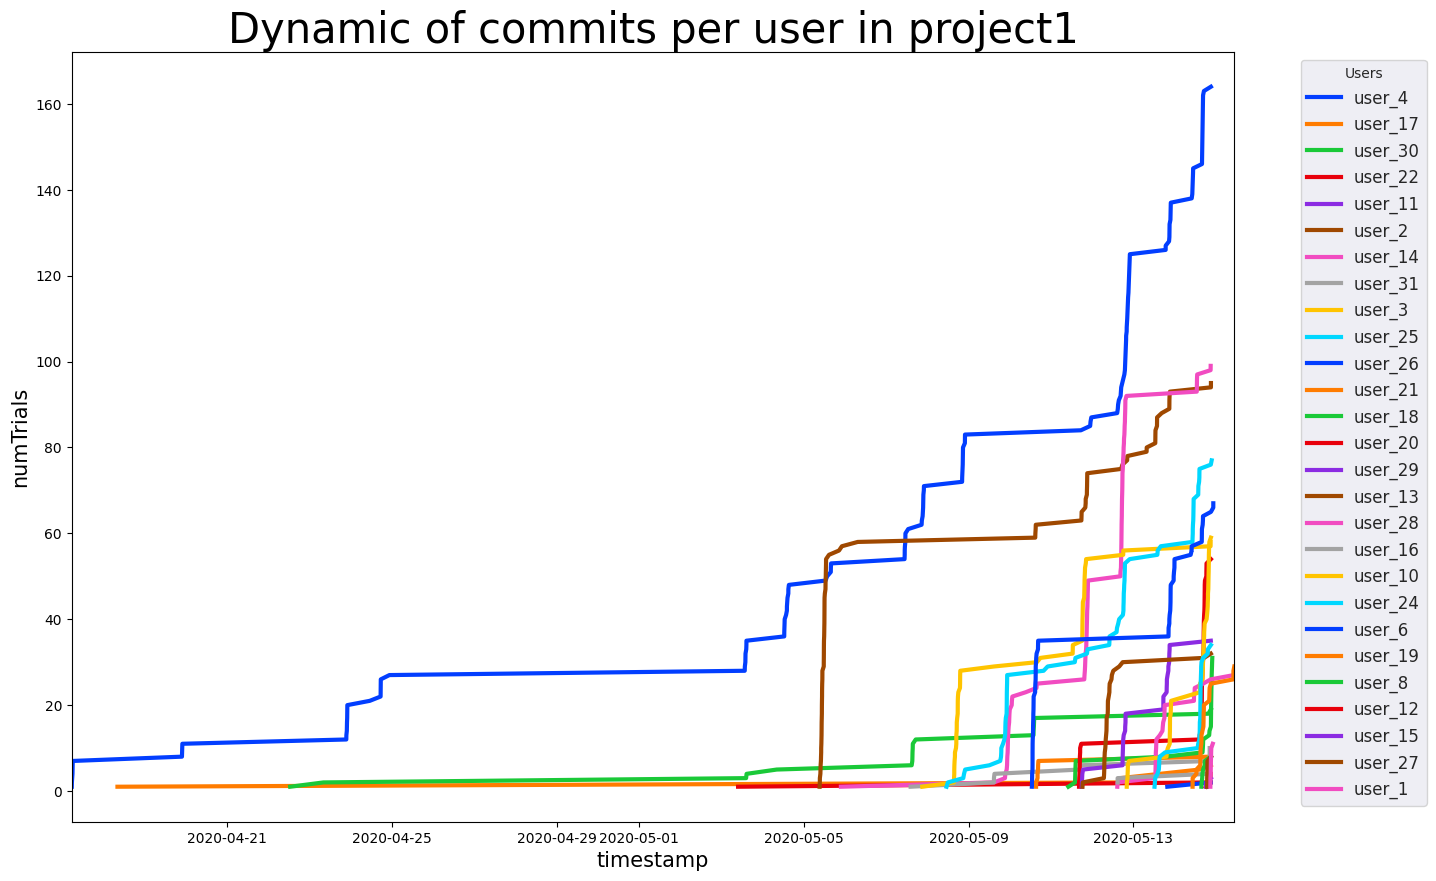

In [4]:
fig, ax = plt.subplots(figsize=(15, 10))

sns.lineplot(x='timestamp', 
             y='numTrials', 
             data=df, 
             hue='uid',
             linewidth=3,
             ax=ax,
             palette="bright"
             )

sns.set_style("darkgrid")
ax.set_xlabel("timestamp", fontsize=15)
ax.set_ylabel("numTrials", fontsize=15)
ax.set_xlim(df['timestamp'].min(), df['timestamp'].max())

ax.legend(title="Users", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=12)

ax.set_title("Dynamic of commits per user in project1", fontsize=30, pad=-30)

plt.show()

## «Какой пользователь был лидером по количеству коммитов почти все время?» 

Ответ: user_4.

## «Какой пользователь был лидером только короткий промежуток времени?» 

Ответ: user_2.